# Day 10: Decision Trees and Random Forests  
## Interpretable AI, Overfitting, Ensembles, and Feature Importance

This notebook introduces tree-based machine learning models.

Students will learn:

- How Decision Trees make predictions
- Why unconstrained trees can overfit
- How to visualize a tree
- Why Random Forests improve stability
- How ensembles reduce variance
- How feature importance helps explain model decisions

We will continue using the **Multimodal Autograder** theme.

The model will predict whether a student passes the semester using:

- Text morphology score
- Spatial vision score
- Attendance

---

# Setup

In Google Colab, these libraries are usually already installed.

If needed, run:

```python
!pip install scikit-learn seaborn matplotlib pandas numpy
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Day 10 Tree-Based ML Environment Initialized.")
np.random.seed(42)

Day 10 Tree-Based ML Environment Initialized.


---

# 1. Generating the Multimodal Autograder Dataset

## Explanation

We will create a synthetic dataset for 123 students.

Each student has three features:

| Feature | Meaning |
|---|---|
| `Text_Score` | Score in text morphology / NLP assignment |
| `Vision_Score` | Score in spatial vision / CV assignment |
| `Attendance` | Attendance percentage |

The label is:

| Label | Meaning |
|---|---|
| `0` | Fail |
| `1` | Pass |

The pass/fail label is created using a weighted combination of the three features.

This gives us a realistic supervised classification problem.

In [ ]:
n_students = 123
text_scores = np.random.normal(75, 12, n_students)
vision_scores = np.random.normal(70, 15, n_students)
attendance = np.random.randint(60, 100, n_students)

labels = np.where(
    (text_scores * 0.4 + vision_scores * 0.4 + attendance * 0.2) > 72,
    1,
    0
)

df = pd.DataFrame({
    "Text_Score": text_scores,
    "Vision_Score": vision_scores,
    "Attendance": attendance,
    "Pass": labels
})

X = df[["Text_Score", "Vision_Score", "Attendance"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Complete. Ready for Tree architectures.")
display(df.head())

Data Split Complete. Ready for Tree architectures.


,Text_Score,Vision_Score,Attendance,Pass
0,80.960570,48.972234,60,0
1,73.340828,78.802856,93,1
2,82.772262,102.856834,91,1
3,93.276358,55.141955,84,1
4,72.190160,61.505534,99,1


## Quick Dataset Check

Before training any model, we should inspect:

- Dataset shape
- Class balance
- Summary statistics

Class balance is important because a classifier can become biased if one class is much larger than the other.

In [3]:
print("Dataset shape:", df.shape)

print("Class counts:")
display(df["Pass"].value_counts())

print("Summary statistics:")
display(df.describe())

Dataset shape: (123, 4)
Class counts:


Pass
1    83
0    40
Name: count, dtype: int64

Summary statistics:


,Text_Score,Vision_Score,Attendance,Pass
count,123.000000,123.000000,123.000000,123.000000
mean,74.198454,70.800971,80.934959,0.674797
std,11.159746,15.002298,11.343908,0.470367
min,43.563059,39.622861,60.000000,0.000000
25%,68.022443,58.550790,71.000000,0.000000
50%,74.135879,72.597714,83.000000,1.000000
75%,80.404590,79.639827,91.000000,1.000000
max,104.558905,127.790972,99.000000,1.000000


## Visualization: Pass vs Fail Distribution

This chart shows whether our dataset is balanced or imbalanced.

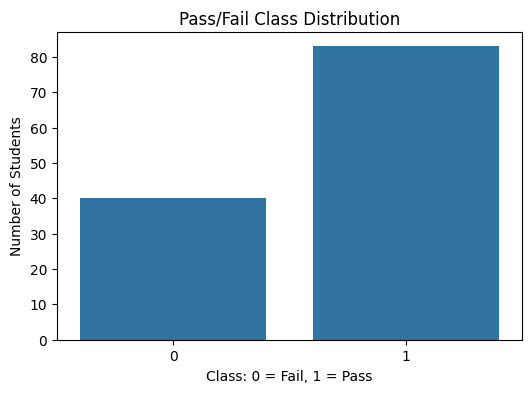

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Pass", data=df)
plt.title("Pass/Fail Class Distribution")
plt.xlabel("Class: 0 = Fail, 1 = Pass")
plt.ylabel("Number of Students")
plt.show()

---

# 2. Training an Unconstrained Decision Tree

## Explanation

A Decision Tree learns a sequence of yes/no questions.

Example:

```text
Is Text_Score <= 71?
Is Attendance <= 82?
Is Vision_Score <= 69?
```

The model keeps splitting the data until it reaches final prediction leaves.

If we do not restrict the tree, it can grow too deep and memorize the training data.

This is called **overfitting**.

Overfitting means:

- Training accuracy becomes very high
- Testing accuracy may drop
- The model memorizes instead of generalizing

In [5]:
unconstrained_tree = DecisionTreeClassifier(random_state=42)
unconstrained_tree.fit(X_train, y_train)

train_acc = unconstrained_tree.score(X_train, y_train)
test_acc = unconstrained_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc * 100:.2f}% (Possible Memorization)")
print(f"Testing Accuracy: {test_acc * 100:.2f}% (Generalization Check)")
print(f"Tree Depth Reached: {unconstrained_tree.get_depth()} levels")
print(f"Number of Leaves: {unconstrained_tree.get_n_leaves()}")

Training Accuracy: 100.00% (Possible Memorization)
Testing Accuracy: 88.00% (Generalization Check)
Tree Depth Reached: 6 levels
Number of Leaves: 13


## Teaching Point: Train Accuracy vs Test Accuracy

If training accuracy is much higher than testing accuracy, that is a warning sign.

The model may have memorized the training data.

A good model should perform well on unseen test data, not only on training data.

---

# 3. Visualizing the Decision Tree

## Explanation

The greatest advantage of a single Decision Tree is interpretability.

We can see the exact logic the algorithm created.

However, a full tree may be too large to read.

So we train a shallow tree with `max_depth=3` to make the visualization understandable.

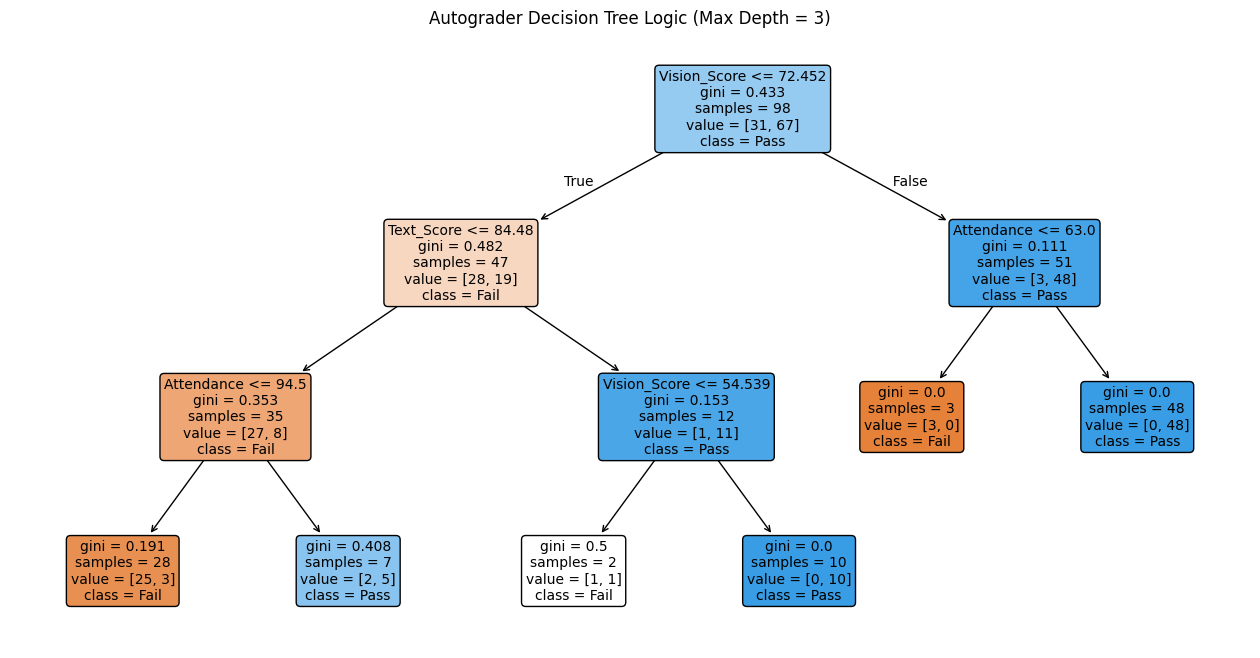

In [6]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(
    shallow_tree,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Autograder Decision Tree Logic (Max Depth = 3)")
plt.show()

## How to Read the Tree

Each box is a decision node or leaf.

Important parts:

| Term | Meaning |
|---|---|
| Feature condition | The yes/no question used for splitting |
| Gini | How mixed the classes are |
| Samples | Number of training examples at that node |
| Value | Count of examples from each class |
| Class | Final predicted class at that node |

Lower Gini means the node is more pure.

---

# Extra Cell 1: Print Tree Rules as Text

## Explanation

Sometimes a text version of the tree is easier to explain than the visual diagram.

This shows the rule structure learned by the shallow tree.

In [ ]:
tree_rules = export_text(shallow_tree, feature_names=list(X.columns))
print(tree_rules)

---

# Extra Cell 2: Controlling Overfitting with `max_depth`

## Explanation

One way to reduce overfitting is to limit tree depth.

A shallow tree may generalize better because it cannot memorize every small detail.

Here we compare different depth values.

In [ ]:
depth_values = range(1, 11)
train_scores = []
test_scores = []

for depth in depth_values:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(list(depth_values), train_scores, marker="o", label="Training Accuracy")
plt.plot(list(depth_values), test_scores, marker="s", label="Testing Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

As depth increases, training accuracy usually increases.

But testing accuracy may stop improving or even decrease.

That is the overfitting pattern.

---

# 4. The Ensemble Upgrade: Random Forest

## Explanation

A single Decision Tree is easy to understand, but it can be unstable.

Small changes in the data can create a different tree.

A Random Forest solves this by training many trees and combining their predictions.

This is called an **ensemble**.

A Random Forest uses two types of randomness:

1. Random rows of data for each tree  
2. Random subset of features at each split  

This reduces overfitting and improves stability.

In [ ]:
forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

forest.fit(X_train, y_train)

rf_train_acc = forest.score(X_train, y_train)
rf_test_acc = forest.score(X_test, y_test)

print("--- Random Forest Performance ---")
print(f"Training Accuracy: {rf_train_acc * 100:.2f}%")
print(f"Testing Accuracy: {rf_test_acc * 100:.2f}%")
print("Random Forest usually reduces the train/test gap compared with a single overgrown tree.")

---

# Extra Cell 3: Decision Tree vs Random Forest Comparison

## Explanation

This chart compares the training and testing accuracy of:

- Unconstrained Decision Tree
- Random Forest

The goal is to show why ensembles are useful.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Decision Tree", "Random Forest", "Random Forest"],
    "Split": ["Train", "Test", "Train", "Test"],
    "Accuracy": [train_acc, test_acc, rf_train_acc, rf_test_acc]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Accuracy", hue="Split", data=comparison_df)
plt.title("Decision Tree vs Random Forest Accuracy")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.show()

display(comparison_df)

---

# 5. Extracting Feature Importance

## Explanation

Random Forest can estimate which features were most useful for making predictions.

This is called **feature importance**.

For our autograder dataset, it tells us whether student success was influenced more by:

- Text score
- Vision score
- Attendance

Feature importance is useful for:

- Model explainability
- Feature selection
- EDA
- Understanding what drives predictions

In [ ]:
importances = forest.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
plt.title("Random Forest: Feature Importance")
plt.xlabel("Gini Importance")
plt.ylabel("Course Metric")
plt.show()

print("Detailed Importance Weights:")
for _, row in feat_df.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

## Important Warning About Feature Importance

Feature importance does not always prove causation.

It tells us which features helped the model split the data.

A feature can be important for prediction without being the true real-world cause.

---

# Extra Cell 4: Confusion Matrix for Random Forest

## Explanation

For classification problems, accuracy alone is not enough.

A confusion matrix shows:

- Correct fail predictions
- Correct pass predictions
- False pass predictions
- False fail predictions

In [ ]:
rf_pred = forest.predict(X_test)

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Random Forest Confusion Matrix")
plt.show()

print(classification_report(y_test, rf_pred, target_names=["Fail", "Pass"]))

---

# Extra Cell 5: Predicting a New Student

## Explanation

After training the model, we can predict whether a new student will pass.

Suppose a student has:

- Text score: 82
- Vision score: 76
- Attendance: 88

The model returns both a class prediction and class probabilities.

In [ ]:
new_student = pd.DataFrame({
    "Text_Score": [82],
    "Vision_Score": [76],
    "Attendance": [88]
})

prediction = forest.predict(new_student)[0]
prediction_proba = forest.predict_proba(new_student)[0]

display(new_student)

print("Predicted class:", "Pass" if prediction == 1 else "Fail")
print(f"Probability of Fail: {prediction_proba[0]:.4f}")
print(f"Probability of Pass: {prediction_proba[1]:.4f}")

---

# Extra Cell 6: Random Forest with More Trees

## Explanation

`n_estimators` controls how many trees are in the forest.

More trees can make the model more stable, but training may become slower.

Here we compare different forest sizes.

In [ ]:
tree_counts = [10, 25, 50, 100, 200]
rf_test_scores = []

for count in tree_counts:
    temp_forest = RandomForestClassifier(
        n_estimators=count,
        max_depth=5,
        random_state=42
    )
    temp_forest.fit(X_train, y_train)
    rf_test_scores.append(temp_forest.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, rf_test_scores, marker="o")
plt.title("Random Forest: Number of Trees vs Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

for count, score in zip(tree_counts, rf_test_scores):
    print(f"{count} trees -> Test Accuracy: {score * 100:.2f}%")

---

# Day 10 Hands-On Coding Test

The following problems are for students to solve independently.

No solutions are provided in this section.

# Test 1: Easy  
## Train a Decision Tree

### Concepts Tested

- DataFrame creation
- Feature matrix `X`
- Target vector `y`
- Train-test split
- Decision Tree training
- Accuracy

## Problem Statement

Create this dataset:

```python
data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Pass": [0, 0, 0, 1, 1, 1, 1, 1]
})
```

Write Python code to:

1. Create `X` using `Hours_Studied` and `Attendance`
2. Create `y` using `Pass`
3. Split the data using `test_size=0.25` and `random_state=42`
4. Train a `DecisionTreeClassifier`
5. Print training accuracy
6. Print testing accuracy

In [ ]:
# Test 1 Student Code

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Pass": [0, 0, 0, 1, 1, 1, 1, 1]
})

# Write your solution here

---

# Test 2: Medium  
## Visualize a Shallow Decision Tree

### Concepts Tested

- Decision Tree
- `max_depth`
- `plot_tree`
- Feature names
- Class names

## Problem Statement

Using the same dataset from Test 1:

1. Train a new `DecisionTreeClassifier` with `max_depth=2`
2. Visualize the tree using `plot_tree`
3. Use feature names
4. Use class names `["Fail", "Pass"]`
5. Add a title to the plot

In [ ]:
# Test 2 Student Code

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Use the dataset from Test 1 or recreate it here

# Write your solution here

---

# Test 3: Hard  
## Random Forest Feature Importance

### Concepts Tested

- Random Forest
- Train-test split
- Model evaluation
- Feature importance
- Bar plot

## Problem Statement

Create this dataset:

```python
np.random.seed(7)
n = 100

math_score = np.random.normal(75, 10, n)
coding_score = np.random.normal(80, 12, n)
attendance = np.random.randint(50, 100, n)

pass_label = ((math_score * 0.4 + coding_score * 0.4 + attendance * 0.2) > 75).astype(int)
```

Write Python code to:

1. Create a DataFrame with `Math_Score`, `Coding_Score`, `Attendance`, and `Pass`
2. Create `X` and `y`
3. Split the data using `test_size=0.2` and `random_state=42`
4. Train a `RandomForestClassifier` with `n_estimators=100`, `max_depth=4`, and `random_state=42`
5. Print training accuracy
6. Print testing accuracy
7. Extract feature importance values
8. Create a bar plot of feature importance

In [ ]:
# Test 3 Student Code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

np.random.seed(7)
n = 100

math_score = np.random.normal(75, 10, n)
coding_score = np.random.normal(80, 12, n)
attendance = np.random.randint(50, 100, n)

pass_label = ((math_score * 0.4 + coding_score * 0.4 + attendance * 0.2) > 75).astype(int)

# Write your solution here

---

# End of Day 10 Notebook

By the end of this notebook, students should understand:

- How Decision Trees split data
- Why unconstrained trees can overfit
- How `max_depth` controls complexity
- How to visualize a tree
- Why Random Forests are stronger than a single tree
- How ensembles reduce variance
- How to extract and interpret feature importance
- Why feature importance helps explain ML models

This prepares students for ensemble learning, XGBoost, model explainability, and applied AI project work.